# EDA CLASE 28 DE MARZO:

## Hipótesis previas

1. Cuanto mas fuma, mayor % de target.

Qué características demográficas, de estilo de vida y clínicas de un paciente se asocian a un mayor riesgo de desarrollar enfermedad coronaria en los próximos 10 años?

## Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## Lectura de datos

In [2]:
from pathlib import Path

ruta = Path('data/framingham.csv')
if not ruta.exists():
    ruta = Path('../data/framingham.csv')

df = pd.read_csv(ruta)
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


El dataset recoge información de un tipo de investigación epidemiológica que sigue a un grupo de individuos a lo largo del tiempo para para determinar la historia natural de determinadas enfermedades e identificar los factores que explican su desarrollo.
La variable **TenYearCHD** será la varaible objetivo del análisis, que indica si el paciente desarrolló enfermedad coronaria en los diez años siguientes.


## Exploración inicial del dataset
Analizamos la dimensión, tipos de variables y presencia de valores nulos y duplicados.

In [3]:
df.shape

(4240, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [7]:
df.describe(include='all')

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [7]:
# Valores nulos por variable
df.isnull().sum().sort_values(ascending=False)

glucose            388
education          105
BPMeds              53
totChol             50
cigsPerDay          29
BMI                 19
heartRate            1
male                 0
age                  0
currentSmoker        0
prevalentStroke      0
prevalentHyp         0
diabetes             0
sysBP                0
diaBP                0
TenYearCHD           0
dtype: int64

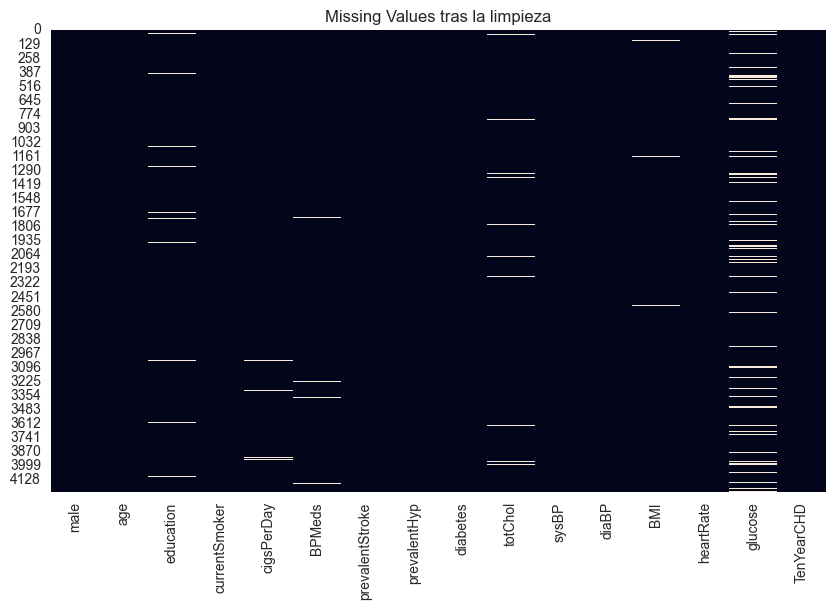

In [ ]:
# Gráfico para ver los nulos
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values tras la limpieza")
plt.show()

In [ ]:
# En este codigo uso la IA
# Para tratar los nulos:
# Las varibles numéricas, las imputo por la mediana
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Las vairables categóricas, las imputo por la moda
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/var/folders/hd/8wn9w5tj7kj6bztqkq_280b40000gn/T/ipykernel_4491/2308946451.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Observaciones:
- El dataset presenta valores nulos en varias variables clave como BMI, glucosa y colesterol.
- He decidido imputar por la mediana para conservar los datos.

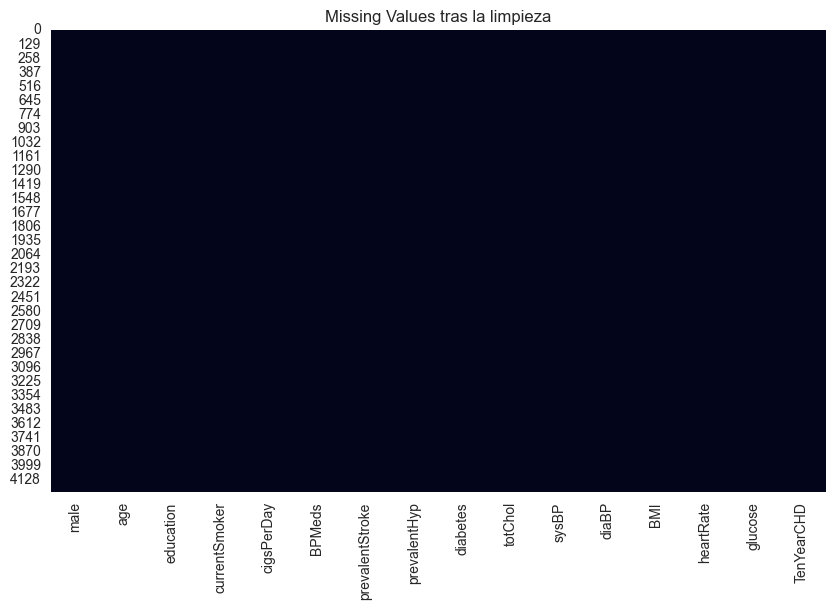

In [16]:
# Hago una segunda comprobación de los nulos
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values tras la limpieza")
plt.show()

In [15]:
# Comprobación de duplicados
df.duplicated().sum()

np.int64(0)

#### Observaciones:
- El dataset tiene **4.240 filas y 16 columnas**. 
- Las variables con valores nulos es **glucose** (388 registros nulos), **education** (105 registros nulos), **BPMeds** (53 registros nulos), **totChol** (50 registros nulos), **cigsPerDay** (29 registros nulos), **BMI** (19 registros nulos) y **heartRate** (con un registro nulo) . 
- No hay filas duplicadas, lo que sugiere que cada registro corresponde a un participante único.
- La variable **prevalentStroke** parece constante: si no aportan varianza, son ruido para el modelo. (hay que verlo)

## Limpieza de datos

### Eliminación de la variable constante
La vairable **prevalentStroke** toma siempre el mismo valor en todos los registros.
Una variable constante tiene varianza cero y, por tanto, correlación cero con cualquier otra variable: no puede aportar información predictiva ni descriptiva.

In [ ]:
# TODAVIA NO EJECUTAR POR SI ACASO:
# df.drop(columns=['prevalentStroke'], inplace=True)
print("Columnas eliminadas: prevalentStroke")
print("Columnas restantes:", df.shape[1])

## Análisis Univariable

### Estadísticas descriptivas

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


In [13]:
# Estadísticas de variables categóricas (NO funciona porque las variables estan codificadas.)
# df.describe(include='object').T

En el documento del estudio pone que hay 6 variables categóricas, pero estas al estar codificadas no permiten verlas con el metodo describe.

In [14]:
# Almacenamos columnas numéricas para usarlas después
num_columns = df.select_dtypes(include='number').columns
num_columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [17]:
# IQR de todas las variables numéricas
# El IQR mide la dispersión del 50% central de los datos, más robusto que la desviación estándar ante outliers
df.describe().T['75%'] - df.describe().T['25%']

male                1.00
age                14.00
education           2.00
currentSmoker       1.00
cigsPerDay         20.00
BPMeds              0.00
prevalentStroke     0.00
prevalentHyp        1.00
diabetes            0.00
totChol            57.00
sysBP              27.00
diaBP              15.00
BMI                 4.97
heartRate          15.00
glucose            16.00
TenYearCHD          0.00
dtype: float64

In [18]:
# Asimetría (skewness)
# valor > 0 -> cola larga a la derecha (valores extremos altos)
# valor = 0 -> distribución simétrica
# valor < 0 -> cola larga a la izquierda (valores extremos bajos)
df[num_columns].skew()

male                0.285997
age                 0.228867
education           0.688730
currentSmoker       0.023595
cigsPerDay          1.247052
BPMeds              5.551462
prevalentStroke    12.912160
prevalentHyp        0.818827
diabetes            5.995907
totChol             0.871881
sysBP               1.145285
diaBP               0.713250
BMI                 0.982183
heartRate           0.644372
glucose             6.214948
TenYearCHD          1.940516
dtype: float64

In [19]:
# Curtosis
# valor > 0 -> distribución leptocúrtica (picos altos, colas pesadas)
# valor = 0 -> distribución mesocúrtica (normal)
# valor < 0 -> distribución platicúrtica (distribución aplanada)
df[num_columns].kurt()

male                -1.919111
age                 -0.989895
education           -0.714357
currentSmoker       -2.000387
cigsPerDay           1.019418
BPMeds              28.832500
prevalentStroke    164.801623
prevalentHyp        -1.330151
diabetes            33.966925
totChol              4.129889
sysBP                2.156624
diaBP                1.275314
BMI                  2.657310
heartRate            0.907396
glucose             58.703741
TenYearCHD           1.766436
dtype: float64

Analizando la curtosis de las vairables podemos ver hay la variable **currentSmoker** destaca por tener una distribución leptocúrtica, es decir tiene unos picos muy altos y unas colas mas pesadas. 
La variable 



### Distribuciones de variables numéricas principales


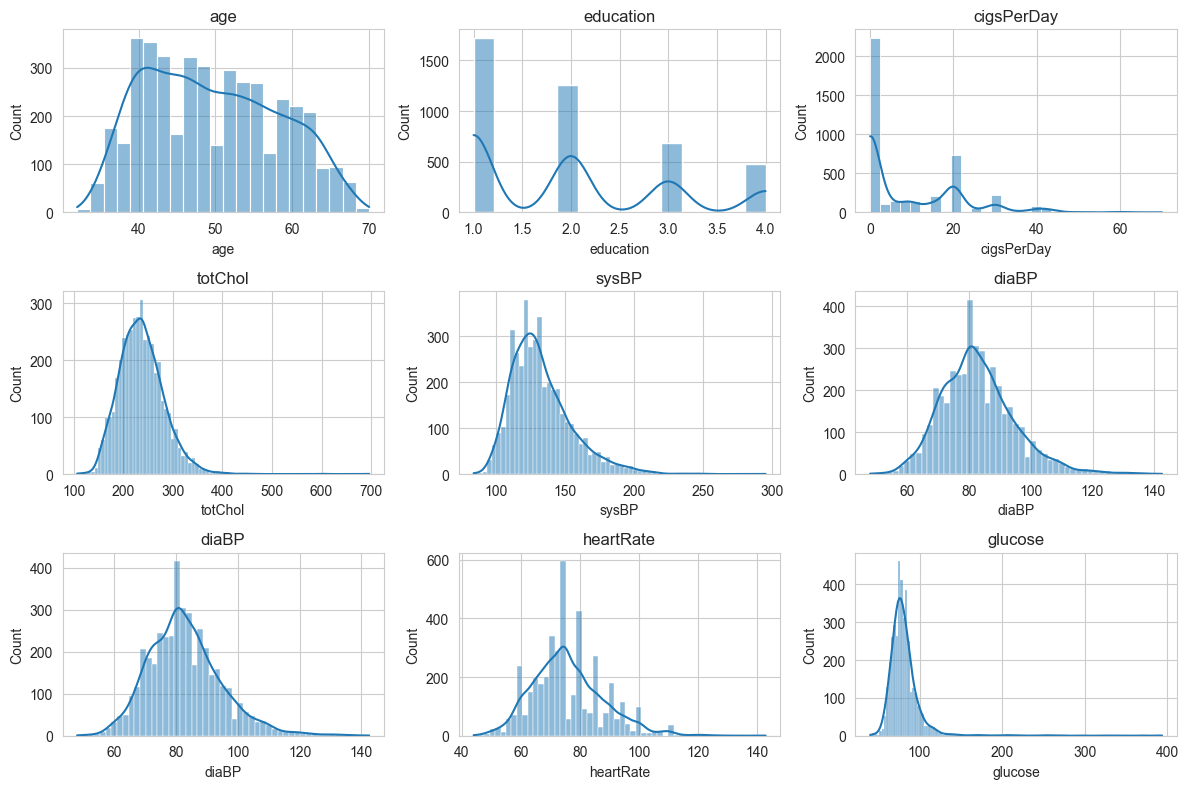

In [27]:
# Solo cojo las variables numéricas pero no binarias.
cols_vis = ['age', 'education', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'diaBP', 'heartRate', 'glucose']
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

for ax, col in zip(axes.flatten(), cols_vis):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

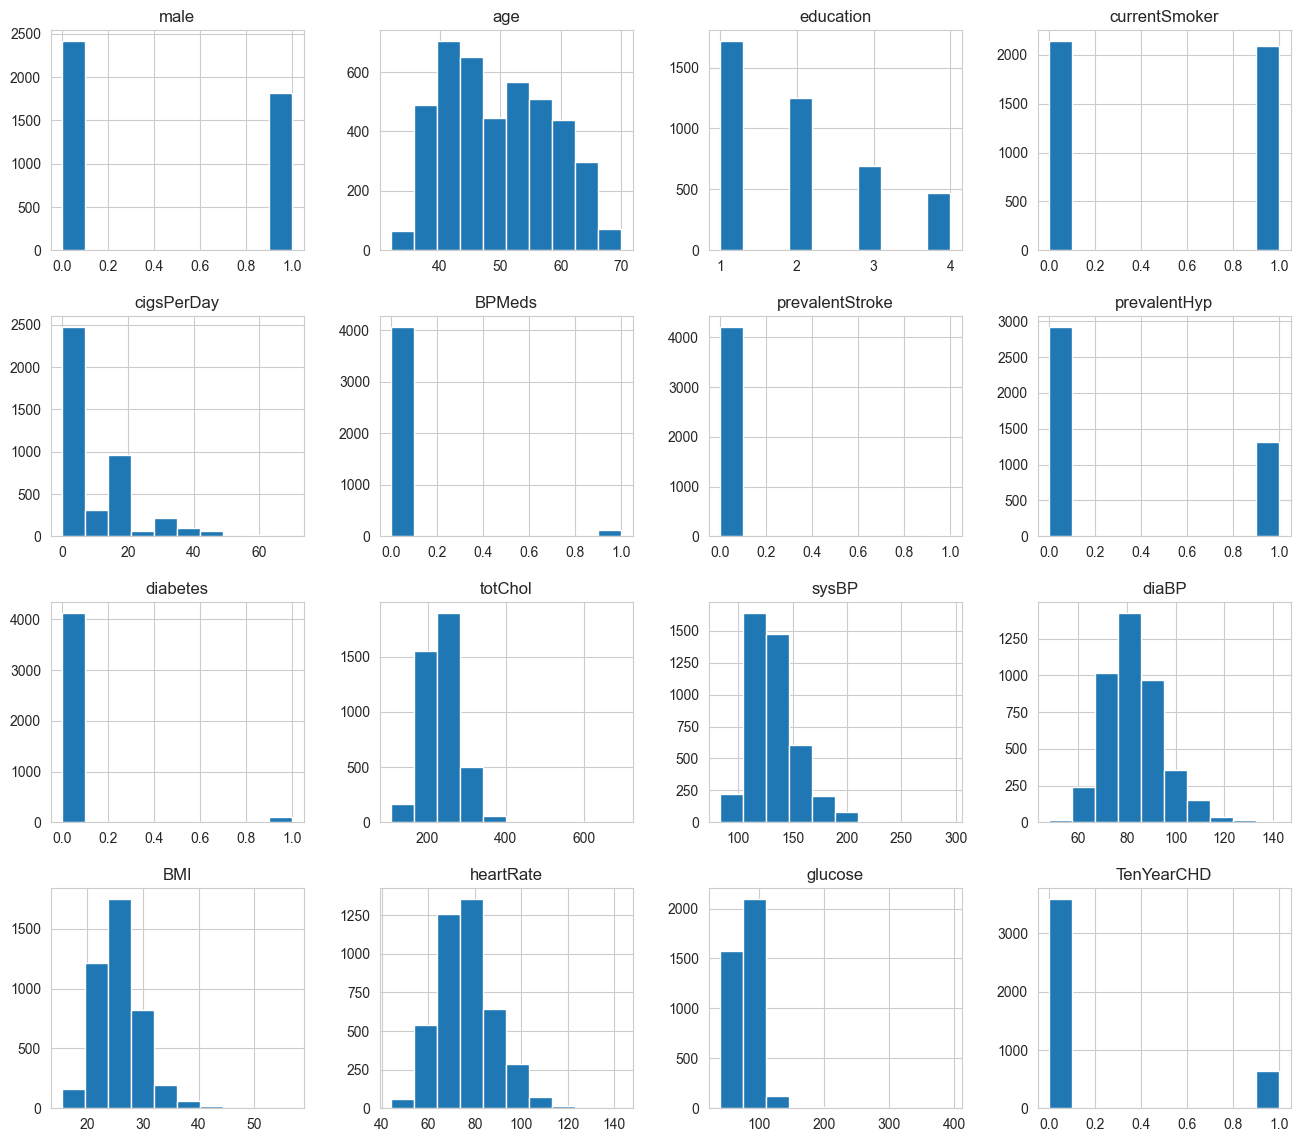

In [20]:
# Histogramas de todas las variables numéricas
df.hist(figsize=(16, 14))
plt.show()

### Distribución de la variable target (**TenYearCHD**)

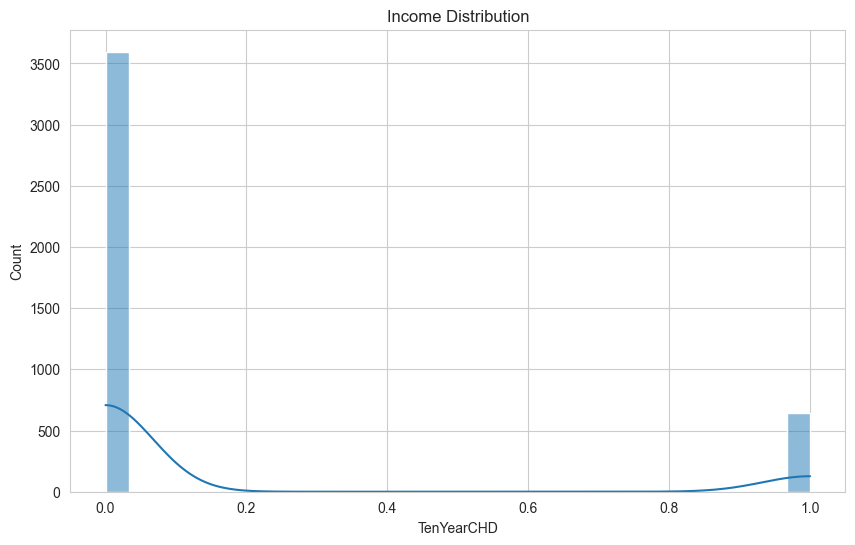

In [ ]:
sns.histplot(df['TenYearCHD'].dropna(), bins=30, kde=True)
plt.title('TenYearCHD Distribution')
plt.show()

## Análisis de la variable objetivo (TenYearCHD)

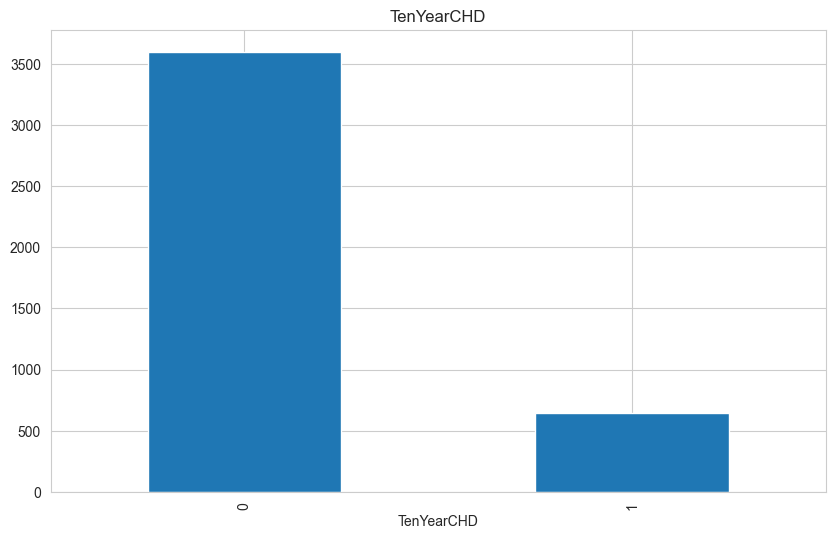

In [28]:
df['TenYearCHD'].value_counts().plot(kind='bar')
plt.title('TenYearCHD')
plt.show()

In [30]:
df['TenYearCHD'].value_counts(normalize=True)

TenYearCHD
0    0.848113
1    0.151887
Name: proportion, dtype: float64

- La variable está muy desbalanceada: **85% no desarrollo una enfermedad coronaria en los 10 años siguientes, y el otro 15% sí la desarrolló.**.
- Para el EDA, este desbalance refuerza la importancia de identificar qué variables discriminan bien entre ambas clases, ya que el perfil de los que sí lo desarrollaron es minoritario pero cualitativamente distinto.

## Correlación entre variables

### Mapa de correlaciones (variables clave)

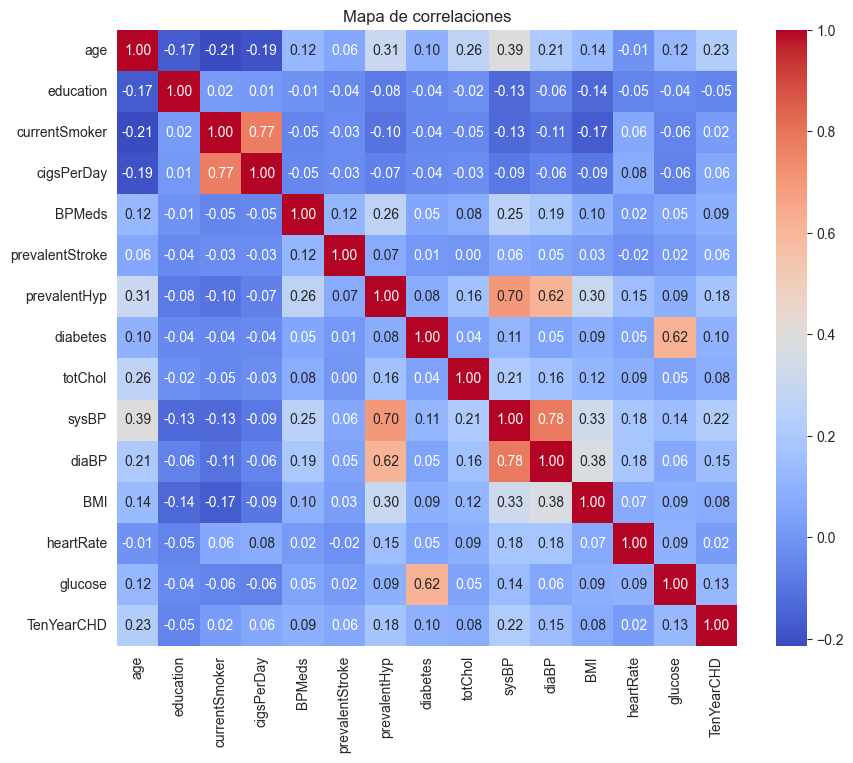

In [11]:
num_cols_corr = [
    'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'     
]

corr = df[num_cols_corr].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de correlaciones')
plt.show()

## Análisis bivariado con male

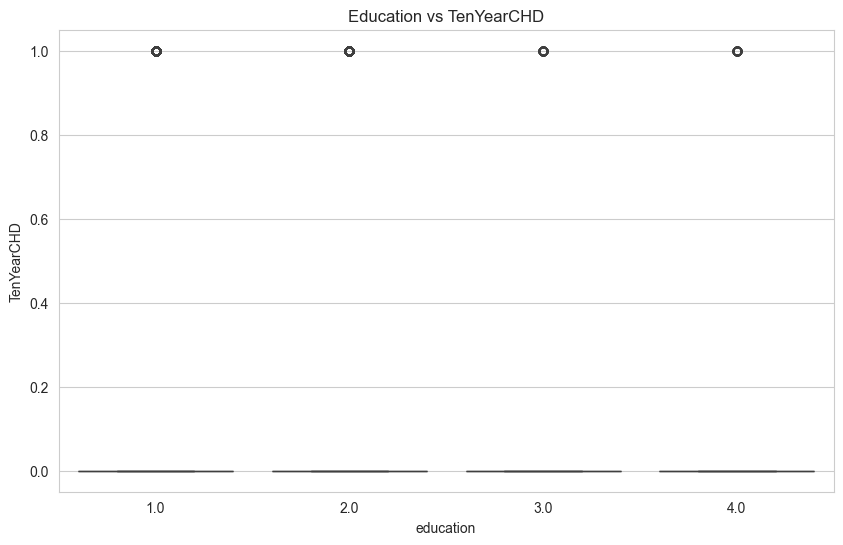

In [ ]:
sns.boxplot(x='education', y='TenYearCHD', data=df)
plt.title('Education vs TenYearCHD')
plt.show()



In [37]:
df['TenYearCHD', 'education'].value_counts().plot(kind='bar')
plt.title('Education vs TenYearCHD')
plt.show()

KeyError: ('TenYearCHD', 'education')